# FIRST ATTEMPT

## Imports

In [184]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import imblearn

# Libraries for splitting, scaling, encoding and feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier


# Libraries for models
from sklearn.svm import SVC 
from sklearn.naive_bayes import BernoulliNB 
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.model_selection import cross_val_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Settings
# pd.set_option('display.max_columns', None)
# import sys
# #np.set_printoptions(threshold=np.nan)
# np.set_printoptions(threshold=sys.maxsize)
# np.set_printoptions(precision=3)
# sns.set(style="darkgrid")
# plt.rcParams['axes.labelsize'] = 14
# plt.rcParams['xtick.labelsize'] = 12
# plt.rcParams['ytick.labelsize'] = 12

## Load and Preview The Data
#### I will be starting with the IDS 2025 data which is not partitioned yet
#### I will then preview the dataset, show its shape and summary statistics

In [185]:
IDS_dataset = pd.read_excel("IDS2025.xlsx")
print(IDS_dataset.head())
print("The dataset has {} rows and {} columns".format(IDS_dataset.shape[0],IDS_dataset.shape[1]))
IDS_dataset.describe()

   Source Port  Destination Port  Protocol  Flow Duration  Total Fwd Packets  \
0        50956               443         6         278351                 10   
1           22              8938         6              2                  1   
2           80             62184         6       24136457                  1   
3        63563                53        17            206                  2   
4        44123                53        17            198                  2   

   Total Backward Packets  Total Length of Fwd Packets  \
0                       5                          588   
1                       2                            0   
2                       5                            6   
3                       2                          112   
4                       2                           66   

   Total Length of Bwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  \
0                         3832                    198                      0   
1         

,Source Port,Destination Port,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,91830.000000,91830.000000,91830.000000,9.183000e+04,91830.000000,91830.000000,9.183000e+04,9.183000e+04,91830.000000,91830.000000,...,91830.000000,9.183000e+04,9.183000e+04,9.183000e+04,9.183000e+04,9.183000e+04,9.183000e+04,9.183000e+04,9.183000e+04,9.183000e+04
mean,45647.012088,5354.885353,7.330654,1.885866e+07,5.341163,5.399521,5.062310e+02,4.952231e+03,147.897343,7.542884,...,2.653577,-8.849659e+02,6.895194e+04,2.341487e+04,9.887980e+04,5.398612e+04,1.514063e+07,6.792253e+05,1.567415e+07,1.464172e+07
std,15736.621194,13659.207657,3.590268,3.641031e+07,76.599861,109.083690,1.541289e+04,2.039694e+05,559.087657,49.722169,...,73.361534,2.768177e+05,5.669143e+05,3.175505e+05,7.675335e+05,5.149367e+05,3.315078e+07,5.700431e+06,3.385886e+07,3.296637e+07
min,0.000000,0.000000,0.000000,-1.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,39583.000000,80.000000,6.000000,4.900000e+01,1.000000,1.000000,0.000000e+00,6.000000e+00,0.000000,0.000000,...,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,50106.000000,80.000000,6.000000,8.975000e+02,2.000000,1.000000,1.400000e+01,6.000000e+00,6.000000,0.000000,...,0.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,56262.750000,2035.000000,6.000000,9.057400e+06,6.000000,5.000000,2.800000e+02,2.745000e+03,195.000000,2.000000,...,2.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65534.000000,65513.000000,17.000000,1.200000e+08,17739.000000,27020.000000,2.866110e+06,5.180000e+07,23360.000000,1983.000000,...,17296.000000,6.000000e+01,2.530000e+07,2.610000e+07,4.160000e+07,2.530000e+07,1.200000e+08,6.650000e+07,1.200000e+08,1.200000e+08


## EDA
#### 1. Check for class imbalance

In [186]:
# Show number of rows for each class
IDS_dataset["newLabel"].value_counts()

# # From the above results, some attack classes make up a very small proportion of the dataset
# # For reporting purposes, I would like to get the percentages of each type of attack

# IDS_dataset["newLabel"].value_counts(normalize=True) * 100


newLabel
Normal          26185
Dos/DDos        26066
PortScan        25409
Brute Force     10201
Web Attack       2067
Botnet ARES      1873
Infiltration       29
Name: count, dtype: int64

#### 2. Data Cleaning - Missing Values

In [187]:
# missing = IDS_dataset.isnull().sum()
# IDS_dataset.isnull().sum().sum()



IDS_dataset.isnull().values.any()

missing = IDS_dataset.isnull().sum()
print(missing[missing > 0])

Flow Bytess    77
dtype: int64


In [188]:
# There are 77 missinng values which I have to fix so I can scale the numeric values without errors

# # These values are in Flow Bytess so let me get a preview of the column
print(IDS_dataset["Flow Bytess"].head(20))

# To know for sure if this is random, I will have to check if this is particular to a certain type of attack 
IDS_dataset[IDS_dataset['Flow Bytess'].isnull()]['newLabel'].value_counts()
# From the result, the null values are mostly concentrated on the DoS/DDoS Attack type

# # Because it is DDoS, check the attack duration. DDoS usually causes really short flow duration
# IDS_dataset[IDS_dataset['Flow Bytess'].isnull()][['Flow Duration', 'newLabel']]
# From the result, all the rows with null flow bytes have 0 duration, whether it is Normal or DDoS attack


0     1.587923e+04
1     0.000000e+00
2     1.491520e+00
3     2.330097e+06
4     1.161616e+06
5     1.470899e+06
6     4.000000e+06
7     1.468964e+03
8     5.898444e+03
9     5.380117e+05
10    0.000000e+00
11    2.284519e+06
12    1.302857e+06
13    3.675144e+03
14    2.130942e+01
15    0.000000e+00
16    5.414471e+03
17    5.111067e+03
18    1.906012e+04
19    5.385141e+03
Name: Flow Bytess, dtype: float64


newLabel
Dos/DDos    73
Normal       4
Name: count, dtype: int64

In [189]:
# Because this is not accidental, i will deal with thiss issue by finding a flag to represent the missing values
# So that I can scale without errors
# However, I may have to create a boolean column with 1/0 for missing/non missing flow bytes values
IDS_dataset['flow_bytes_was_missing'] = IDS_dataset['Flow Bytess'].isnull().astype(int)

# Check the work
print(IDS_dataset['flow_bytes_was_missing'].value_counts())



flow_bytes_was_missing
0    91753
1       77
Name: count, dtype: int64


In [190]:
# The value of Flow Bytes for those 77 rows is null as shown below (It is the flow duration that is 0)
IDS_dataset[IDS_dataset['flow_bytes_was_missing'] == 1]['Flow Bytess'].head()

# To perform calculations on this column, I changed the values to 0
# For reference later, I can always check the 'flow_bytes_was_missing' column to know what was originally missing and what wasn't
IDS_dataset['Flow Bytess'] = IDS_dataset['Flow Bytess'].fillna(0)

# Check the work
print(IDS_dataset['Flow Bytess'].isnull().sum())
# I have dealt with all the null values

0


#### 3. Data Cleaning - Infinite Values

In [191]:
# There are some infinite values in the data which I discovered on my first attempt to scale
# These caused error while working with the numeric fields

numeric_cols = IDS_dataset.select_dtypes(include=['float64', 'int64']).columns
inf_counts = np.isinf(IDS_dataset[numeric_cols]).sum()
print(inf_counts[inf_counts > 0])

# From the result, there were about 50 infinite values under Flow Bytess and 127 under Flow Packetss
# Anyway, this cell be comess redundant after running the next but I'm keeping it for record purposes

Flow Bytess       50
Flow Packetss    127
dtype: int64


In [192]:
# Flag rows with inf values before removing them (same logic as the missing-value flag)

IDS_dataset['flow_had_inf'] = np.isinf(IDS_dataset[numeric_cols]).any(axis=1).astype(int)
print(IDS_dataset['flow_had_inf'].value_counts())

# Check if it's concentrated by class, same check as before
print(IDS_dataset[IDS_dataset['flow_had_inf'] == 1]['newLabel'].value_counts())

# Replace inf with 0 (consistent with how you handled the Flow Bytess NaNs)
IDS_dataset[numeric_cols] = IDS_dataset[numeric_cols].replace([np.inf, -np.inf], 0)

# Confirm no inf values remain
print(np.isinf(IDS_dataset[numeric_cols]).sum().sum())  # should print 0

flow_had_inf
0    91703
1      127
Name: count, dtype: int64
newLabel
Dos/DDos       73
PortScan       22
Normal         20
Botnet ARES     9
Brute Force     3
Name: count, dtype: int64
0


#### 3. Data Cleaning - Duplicated Values

In [193]:
print(IDS_dataset.duplicated().sum())
IDS_dataset = IDS_dataset.drop_duplicates()
# Checked the number of duplicated rows and dropped them

86


## Split Data

In [194]:
# Split the data into y(independent) and x (dependent) variables
x = IDS_dataset.drop(columns=['newLabel'])
y = IDS_dataset['newLabel']

# SPlit the data into train and test while maintaining balance in the proportions of the classes in train/test
# I did this because of the disproportionate representation of classes we noted above
x_train, x_test, y_train, y_test = train_test_split(
    x, y, train_size=0.8, random_state=7, stratify=y
)

## Scale Data

In [195]:
scaler = StandardScaler()

cols = x_train.select_dtypes(include=['float64', 'int64']).columns

sc_train = scaler.fit_transform(x_train[cols])
sc_test = scaler.transform(x_test[cols]) 

sc_traindf = pd.DataFrame(sc_train, columns=cols, index=x_train.index)
sc_testdf = pd.DataFrame(sc_test, columns=cols, index=x_test.index)


## Encode Data

In [196]:
le = LabelEncoder()

# Fit on train labels only, then apply the same mapping to test
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Check what number maps to which class - useful for interpreting results later
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'Botnet ARES': np.int64(0), 'Brute Force': np.int64(1), 'Dos/DDos': np.int64(2), 'Infiltration': np.int64(3), 'Normal': np.int64(4), 'PortScan': np.int64(5), 'Web Attack': np.int64(6)}


In [197]:
# Reassigning data for ease of remembering

X = sc_traindf.copy()
Y = y_train_encoded.copy()

X_TEST = sc_testdf.copy()
Y_TEST = y_test_encoded.copy()

## Feature Selection

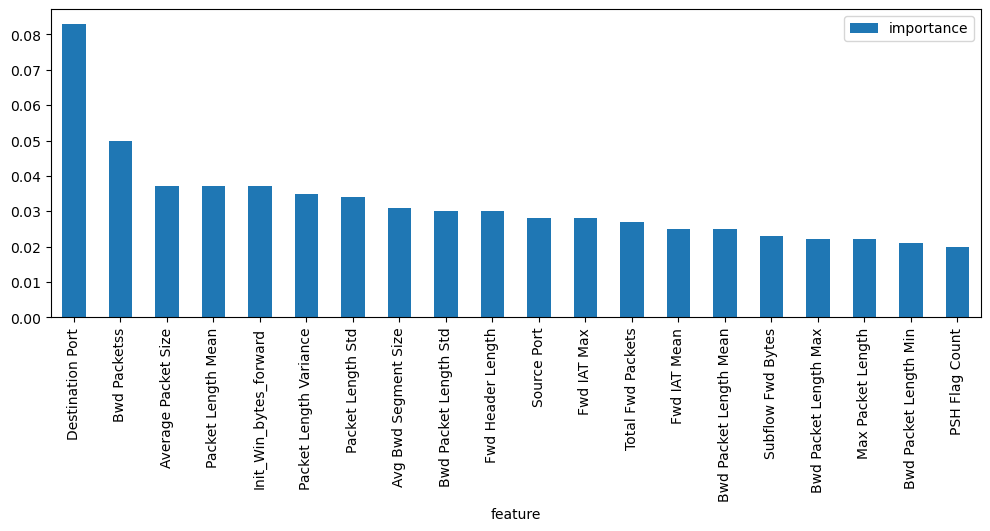

In [198]:

rfc = RandomForestClassifier(random_state=7)
rfc.fit(X, Y)

# Rank features by importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': np.round(rfc.feature_importances_, 3)
}).sort_values('importance', ascending=False).set_index('feature')

# Plot top 20 for readability (80 columns is too many to read on one bar chart)
importances.head(20).plot.bar(figsize=(12, 4))
plt.show()

## Model Training

In [199]:
# KNN
KNN_Classifier = KNeighborsClassifier(n_jobs=-1)
KNN_Classifier.fit(X, Y)

# Logistic Regression
LGR_Classifier = LogisticRegression(n_jobs=-1, random_state=7)
LGR_Classifier.fit(X, Y)

# Bernoulli Naive Bayes
BNB_Classifier = BernoulliNB()
BNB_Classifier.fit(X, Y)

# Decision Tree
DTC_Classifier = tree.DecisionTreeClassifier(criterion='entropy', random_state=7)
DTC_Classifier.fit(X, Y)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


DecisionTreeClassifier(criterion='entropy', random_state=7)

## Model Evaluation

In [200]:
models = []
models.append(('Naive Bayes', BNB_Classifier))
models.append(('Decision Tree', DTC_Classifier))
models.append(('KNN', KNN_Classifier))
models.append(('Logistic Regression', LGR_Classifier))

# Evaluate on training data (with cross-validation)
for name, model in models:
    cv_scores = cross_val_score(model, X, Y, cv=10)
    accuracy = metrics.accuracy_score(Y, model.predict(X))
    conf_matrix = metrics.confusion_matrix(Y, model.predict(X))
    report = metrics.classification_report(Y, model.predict(X))

    print(f"\n===== {name} - Train Evaluation =====")
    print("Cross Validation Mean Score:", cv_scores.mean())
    print("Accuracy:", accuracy)
    print("Confusion Matrix:\n", conf_matrix)
    print("Classification Report:\n", report)


===== Naive Bayes - Train Evaluation =====
Cross Validation Mean Score: 0.7448599267917694
Accuracy: 0.7450780025887322
Confusion Matrix:
 [[ 1071     0     0     0    43   384     0]
 [ 1281  6868     0     1     1    10     0]
 [ 2024  3171 14082   165  1232     0   120]
 [    0     2     0    20     1     0     0]
 [ 3542  1352  2602  1404 11134   440   464]
 [    2     4    42     0    10 20126   143]
 [  108    17    89     0    56     0  1384]]
Classification Report:
               precision    recall  f1-score   support

           0       0.13      0.71      0.22      1498
           1       0.60      0.84      0.70      8161
           2       0.84      0.68      0.75     20794
           3       0.01      0.87      0.02        23
           4       0.89      0.53      0.67     20938
           5       0.96      0.99      0.97     20327
           6       0.66      0.84      0.74      1654

    accuracy                           0.75     73395
   macro avg       0.58      0.7

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite


===== Logistic Regression - Train Evaluation =====
Cross Validation Mean Score: 0.9346957818945703
Accuracy: 0.9363308127256625
Confusion Matrix:
 [[  526     0     0     0   588   384     0]
 [    0  8133    10     0     8    10     0]
 [    8    52 20481     0   252     0     1]
 [    0     1     0    17     5     0     0]
 [  178   512  1733     4 17812   387   312]
 [    1     4    16     0     7 20298     1]
 [    0   112    19     0    65     3  1455]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.35      0.48      1498
           1       0.92      1.00      0.96      8161
           2       0.92      0.98      0.95     20794
           3       0.81      0.74      0.77        23
           4       0.95      0.85      0.90     20938
           5       0.96      1.00      0.98     20327
           6       0.82      0.88      0.85      1654

    accuracy                           0.94     73395
   macro avg       0.88 

## Model Validation

In [ ]:
# Validate the model on test data

for name, model in models:
    accuracy = metrics.accuracy_score(Y_TEST, model.predict(X_TEST))
    conf_matrix = metrics.confusion_matrix(Y_TEST, model.predict(X_TEST))
    report = metrics.classification_report(Y_TEST, model.predict(X_TEST))

    print(f"\n===== {name} - Validation Results =====")
    print("Accuracy:", accuracy)
    print("Confusion Matrix:\n", conf_matrix)
    print("Classification Report:\n", report)
    

# # To do row by row inspection later, I am, saving this here

# pred_knn = KNN_Classifier.predict(test_df)
# pred_NB = BNB_Classifier.predict(test_df)
# pred_log = LGR_Classifier.predict(test_df)
# pred_dt = DTC_Classifier.predict(test_df)



===== Naive Bayes - Validation Results =====
Accuracy: 0.743964248732901
Confusion Matrix:
 [[ 289    0    0    0    9   77    0]
 [ 328 1708    0    1    0    3    0]
 [ 508  782 3538   43  307    0   20]
 [   0    1    1    3    1    0    0]
 [ 886  354  657  351 2752  117  118]
 [   1    0   14    0    4 5026   37]
 [  37    4   20    0   17    0  335]]
Classification Report:
               precision    recall  f1-score   support

           0       0.14      0.77      0.24       375
           1       0.60      0.84      0.70      2040
           2       0.84      0.68      0.75      5198
           3       0.01      0.50      0.01         6
           4       0.89      0.53      0.66      5235
           5       0.96      0.99      0.98      5082
           6       0.66      0.81      0.73       413

    accuracy                           0.74     18349
   macro avg       0.58      0.73      0.58     18349
weighted avg       0.84      0.74      0.77     18349


===== Decision Tre

## Test Data Prediction

In [202]:
pred_knn = KNN_Classifier.predict(X_TEST)
pred_nb = BNB_Classifier.predict(X_TEST)
pred_log = LGR_Classifier.predict(X_TEST)
pred_dt = DTC_Classifier.predict(X_TEST)

Exception ignored in: <function ResourceTracker.__del__ at 0x110f35b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x110b69b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102dd9b20>
Traceback (most recent call last